In [160]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u

### Loading in all the models
sun_simple_model = np.genfromtxt(f'sun_simple_model/trimmed_history.data', skip_header=5, names=True)
different_alpha = np.genfromtxt(f'different_alpha_sun_like_star/trimmed_history.data', skip_header=5, names=True)

sun_simple_model_no_chemical_evolution = np.genfromtxt(f'sun_simple_model_no_chemical_evolution/trimmed_history.data', skip_header=5, names=True)
sun_simple_model_no_energy_release = np.genfromtxt(f'sun_simple_model_no_energy_release/trimmed_history.data', skip_header=5, names=True)
sun_simple_model_no_energy_release_or_chem_evolution = np.genfromtxt(f'sun_simple_model_no_energy_release_or_chem_evolution/trimmed_history.data', skip_header=5, names=True)

sun_z_0_01 = np.genfromtxt(f'sun_z_0_01/trimmed_history.data', skip_header=5, names=True)
sun_z_0_0001 = np.genfromtxt(f'sun_z_0_0001/trimmed_history.data', skip_header=5, names=True)
sun_z_0_03 = np.genfromtxt(f'sun_z_0_03/trimmed_history.data', skip_header=5, names=True)
sun_z_0_004 = np.genfromtxt(f'sun_z_0_004/trimmed_history.data', skip_header=5, names=True)

def return_profile(directory, profile_number):
    return np.genfromtxt(f'{directory}/profile{profile_number}.data', skip_header=5, names=True)

In [161]:
# Printing column names for reference
print('Trimmed history column names:', sun_simple_model.dtype.names, '\n')

Trimmed history column names: ('model_number', 'star_age', 'star_mass', 'log_L', 'log_R', 'log_Teff', 'log_center_T', 'log_center_Rho', 'log_center_P', 'center_h1', 'center_he3', 'center_he4', 'center_c12', 'center_n14', 'center_o16', 'center_ne20', 'center_mg24', 'center_si28', 'center_s32', 'center_ar36', 'center_ca40', 'center_ti44', 'center_cr48', 'center_fe52', 'center_fe54', 'center_fe56', 'center_ni56', 'center_degeneracy', 'center_ye', 'center_entropy', 'compactness_parameter', 'dynamic_timescale', 'kh_timescale', 'nuc_timescale', 'pp', 'cno', 'tri_alfa', 'log_LH', 'log_LHe', 'log_LZ', 'log_Lneu', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'si_core_mass', 'fe_core_mass', 'he_core_radius', 'c_core_radius', 'o_core_radius', 'si_core_radius', 'fe_core_radius', 'max_abs_v_velocity', 'surf_avg_omega_div_omega_crit', 'log_total_angular_momentum', 'surf_avg_omega', 'surf_avg_v_rot', 'star_mdot') 



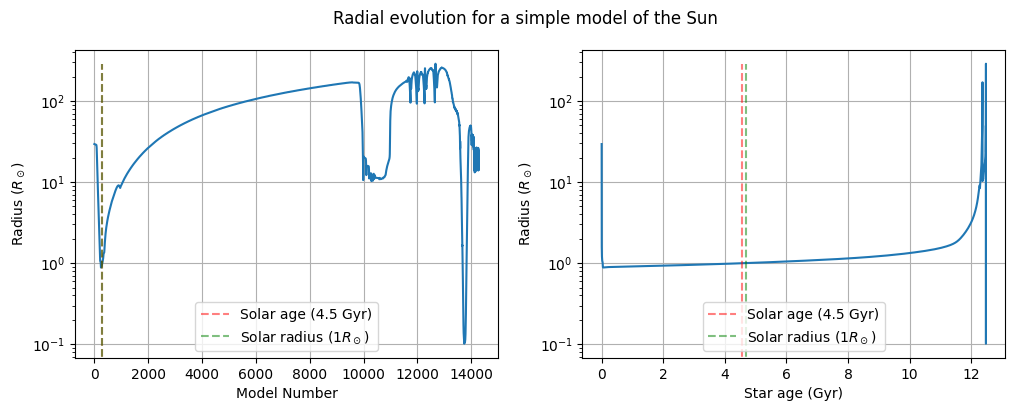

The present day value is 0.99759. The radius equals 1 R_sun at 4.6736e+00 Gyrs.
A planet at 1 AU would be engulfed at t=12476172001.062338 yrs, at model 12099.0.
The maximum age reached by this stellar model was t=12476326503.768513 yrs.


In [162]:
#### A simple model of the Sun ###
model = sun_simple_model

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=False)
fig.suptitle('Radial evolution for a simple model of the Sun')

# Radius vs. model number
ax1.plot(model['model_number'], 10**model['log_R'])
ax1.vlines(model['model_number'][idx_age], ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='red', label='Solar age (4.5 Gyr)', alpha=0.5)
ax1.vlines(model['model_number'][idx_radius], ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='green', label=r'Solar radius (1$R_\odot$)', alpha=0.5)
ax1.grid()
ax1.set_xlabel('Model Number')
ax1.set_ylabel(r'Radius ($R_\odot$)')
ax1.set_yscale('log')
ax1.legend(loc='lower center')

# Radius vs. star age
ax2.plot(model['star_age']/1e9, 10**model['log_R'])
ax2.vlines(model['star_age'][idx_age]/1e9, ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='red', label='Solar age (4.5 Gyr)', alpha=0.5)
ax2.vlines(model['star_age'][idx_radius]/1e9, ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='green', label=r'Solar radius (1$R_\odot$)', alpha=0.5)
ax2.grid()
ax2.set_xlabel('Star age (Gyr)')
ax2.set_ylabel(r'Radius ($R_\odot$)')
ax2.set_yscale('log')
ax2.legend(loc='lower center')

# Save & show figure
plt.savefig(f'Figures/sun_simple_model_radial_evolution', dpi=500, bbox_inches='tight')
plt.show()

# Solar values
idx_age, idx_radius = np.argmin(np.abs(sun_simple_model['star_age'] - 4.5e9)), np.argmin(np.abs(10**sun_simple_model['log_R'] - 1))
print(f"The present day value is {10**sun_simple_model['log_R'][idx_age]:.5f}. The radius equals 1 R_sun at {sun_simple_model['star_age'][idx_radius]/1e9:.4e} Gyrs.")

# Planetary engulfment :D
r_sun_1au = 1*u.AU.to(u.Rsun)
idx_engulfment = np.argmin(abs(10**sun_simple_model['log_R'] - r_sun_1au))
print(f"A planet at 1 AU would be engulfed at t={sun_simple_model['star_age'][idx_engulfment]} yrs, at model {sun_simple_model['model_number'][idx_engulfment]}.")
print(f"The maximum age reached by this stellar model was t={np.max(sun_simple_model['star_age'])} yrs.")

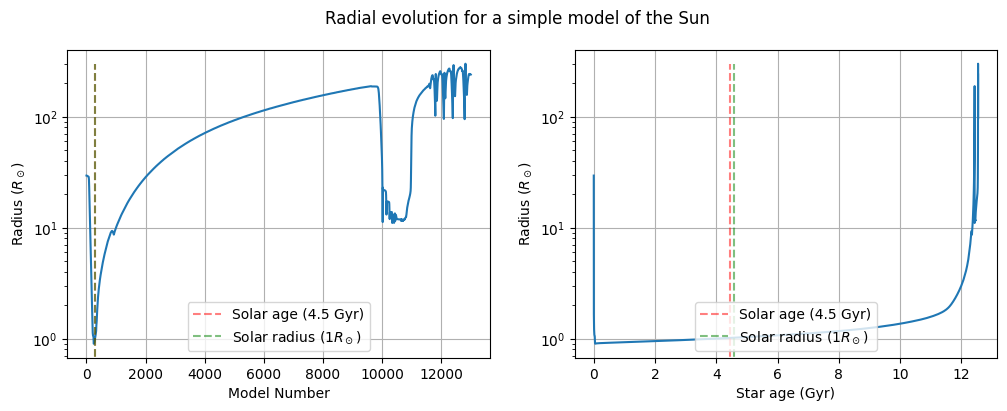

The present day value is 0.99759. The radius equals 1 R_sun at 4.6736e+00 Gyrs.
A planet at 1 AU would be engulfed at t=12476172001.062338 yrs, at model 12099.0.
The maximum age reached by this stellar model was t=12476326503.768513 yrs.


In [163]:
#### A simple model of the Sun ###
model = different_alpha

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey=False)
fig.suptitle('Radial evolution for a simple model of the Sun')

# Radius vs. model number
ax1.plot(model['model_number'], 10**model['log_R'])
ax1.vlines(model['model_number'][idx_age], ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='red', label='Solar age (4.5 Gyr)', alpha=0.5)
ax1.vlines(model['model_number'][idx_radius], ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='green', label=r'Solar radius (1$R_\odot$)', alpha=0.5)
ax1.grid()
ax1.set_xlabel('Model Number')
ax1.set_ylabel(r'Radius ($R_\odot$)')
ax1.set_yscale('log')
ax1.legend(loc='lower center')

# Radius vs. star age
ax2.plot(model['star_age']/1e9, 10**model['log_R'])
ax2.vlines(model['star_age'][idx_age]/1e9, ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='red', label='Solar age (4.5 Gyr)', alpha=0.5)
ax2.vlines(model['star_age'][idx_radius]/1e9, ymin=0, ymax=np.max(10**model['log_R']), linestyle = '--', color='green', label=r'Solar radius (1$R_\odot$)', alpha=0.5)
ax2.grid()
ax2.set_xlabel('Star age (Gyr)')
ax2.set_ylabel(r'Radius ($R_\odot$)')
ax2.set_yscale('log')
ax2.legend(loc='lower center')

# Save & show figure
plt.savefig(f'Figures/different_alpha_radial_evolution', dpi=500, bbox_inches='tight')
plt.show()

# Solar values
idx_age, idx_radius = np.argmin(np.abs(sun_simple_model['star_age'] - 4.5e9)), np.argmin(np.abs(10**sun_simple_model['log_R'] - 1))
print(f"The present day value is {10**sun_simple_model['log_R'][idx_age]:.5f}. The radius equals 1 R_sun at {sun_simple_model['star_age'][idx_radius]/1e9:.4e} Gyrs.")

# Planetary engulfment :D
r_sun_1au = 1*u.AU.to(u.Rsun)
idx_engulfment = np.argmin(abs(10**sun_simple_model['log_R'] - r_sun_1au))
print(f"A planet at 1 AU would be engulfed at t={sun_simple_model['star_age'][idx_engulfment]} yrs, at model {sun_simple_model['model_number'][idx_engulfment]}.")
print(f"The maximum age reached by this stellar model was t={np.max(sun_simple_model['star_age'])} yrs.")

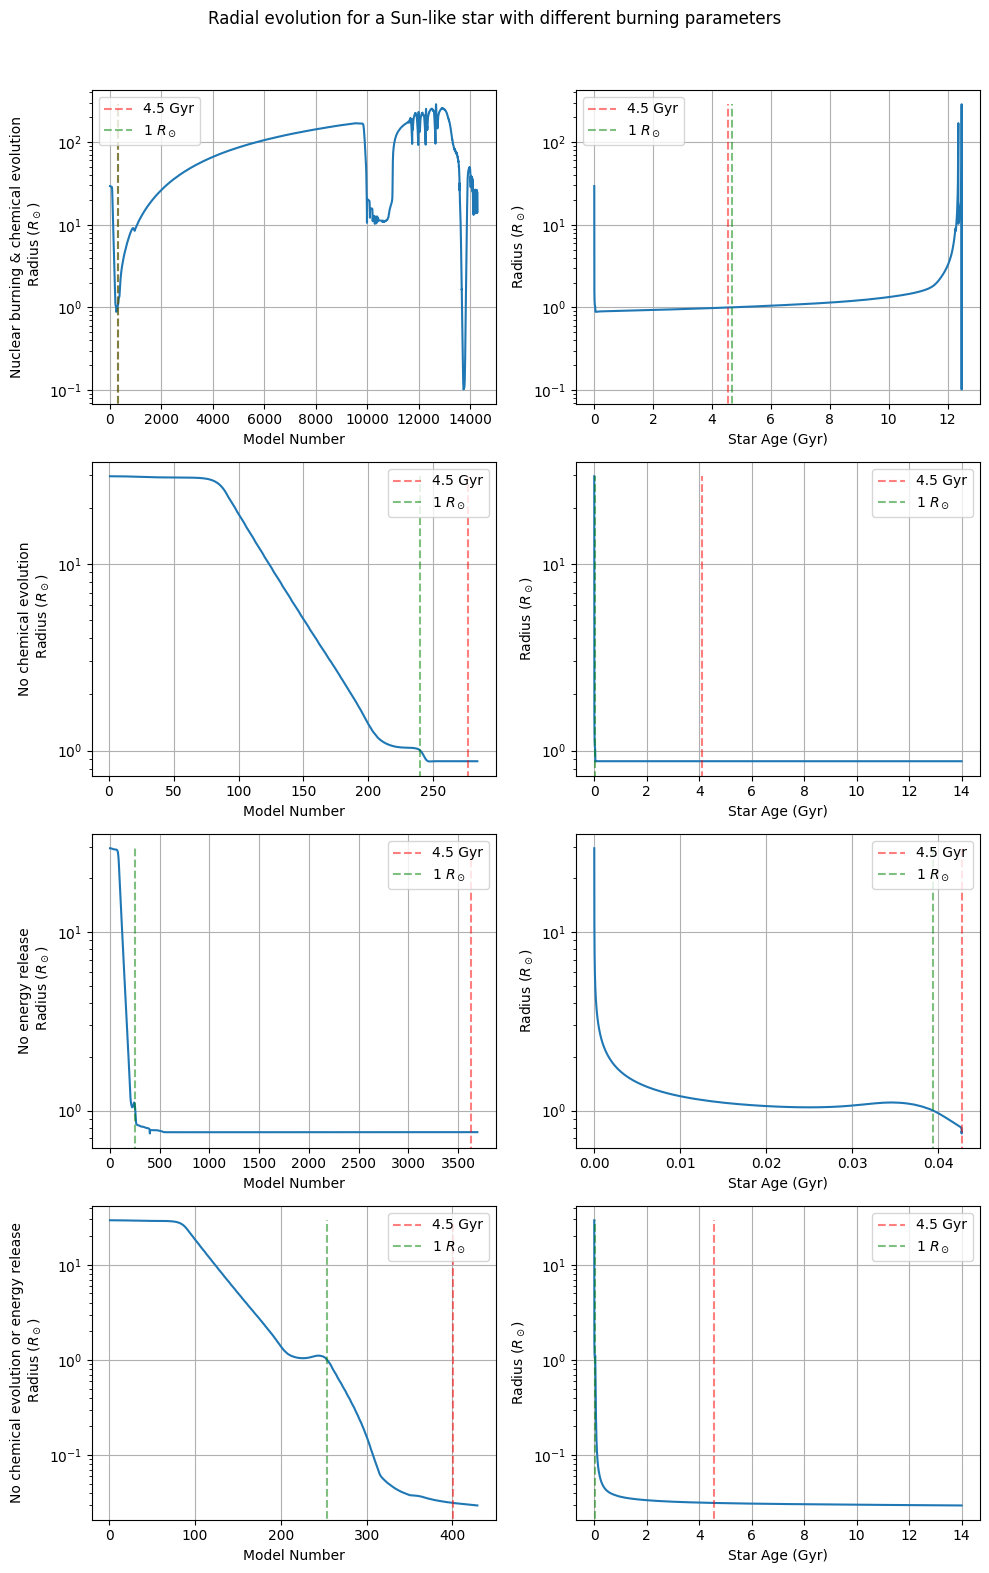

42725669.03588875


In [164]:
### Stellar evolution ###
def plot_radial_profiles_cases(models_by_case, title, saveas):
    cases = list(models_by_case.keys())
    nC = len(cases)
    fig, axes = plt.subplots(nrows=nC,ncols=2,figsize=(10, 4 * nC),sharex=False,sharey=False)
    if nC == 1:
        axes = np.array([axes])
    fig.suptitle(title)
    for i, case in enumerate(cases):
        model = models_by_case[case]
        idx_age, idx_radius = np.argmin(np.abs(model['star_age'] - 4.5e9)), np.argmin(np.abs(10**model['log_R'] - 1))
        ax1, ax2 = axes[i]
        radius = 10**model['log_R']
        maxR = np.max(radius)
        # Radius vs. model number
        ax1.plot(model['model_number'], radius)
        ax1.vlines(model['model_number'][idx_age], 0, maxR,linestyle='--', color='red', alpha=0.5,label='4.5 Gyr')
        ax1.vlines(model['model_number'][idx_radius], 0, maxR,linestyle='--', color='green', alpha=0.5,label=r'1 $R_\odot$')
        ax1.grid()
        ax1.set_xlabel('Model Number')
        ax1.set_ylabel(f'{case}\n Radius '+r'($R_\odot$)')
        ax1.set_yscale('log')
        ax1.legend(loc='best')
        # Radius vs. star age
        age = model['star_age'] / 1e9  # convert to Gyr
        ax2.plot(age, radius)
        ax2.vlines(age[idx_age], 0, maxR,linestyle='--', color='red', alpha=0.5, label='4.5 Gyr')
        ax2.vlines(age[idx_radius], 0, maxR,linestyle='--', color='green', alpha=0.5, label=r'1 $R_\odot$')
        ax2.grid()
        ax2.set_xlabel('Star Age (Gyr)')
        ax2.set_ylabel(r'Radius ($R_\odot$)')
        ax2.set_yscale('log')
        ax2.legend(loc='best')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'Figures/{saveas}_radial_evolution_cases',dpi=500, bbox_inches='tight')
    plt.show()

models_by_case = {'Nuclear burning & chemical evolution': sun_simple_model,'No chemical evolution': sun_simple_model_no_chemical_evolution,'No energy release': sun_simple_model_no_energy_release,'No chemical evolution or energy release': sun_simple_model_no_energy_release_or_chem_evolution}
plot_radial_profiles_cases(models_by_case, 'Radial evolution for a Sun-like star with different burning parameters', 'burningradialprofiles')


print(np.max(sun_simple_model_no_energy_release['star_age']))

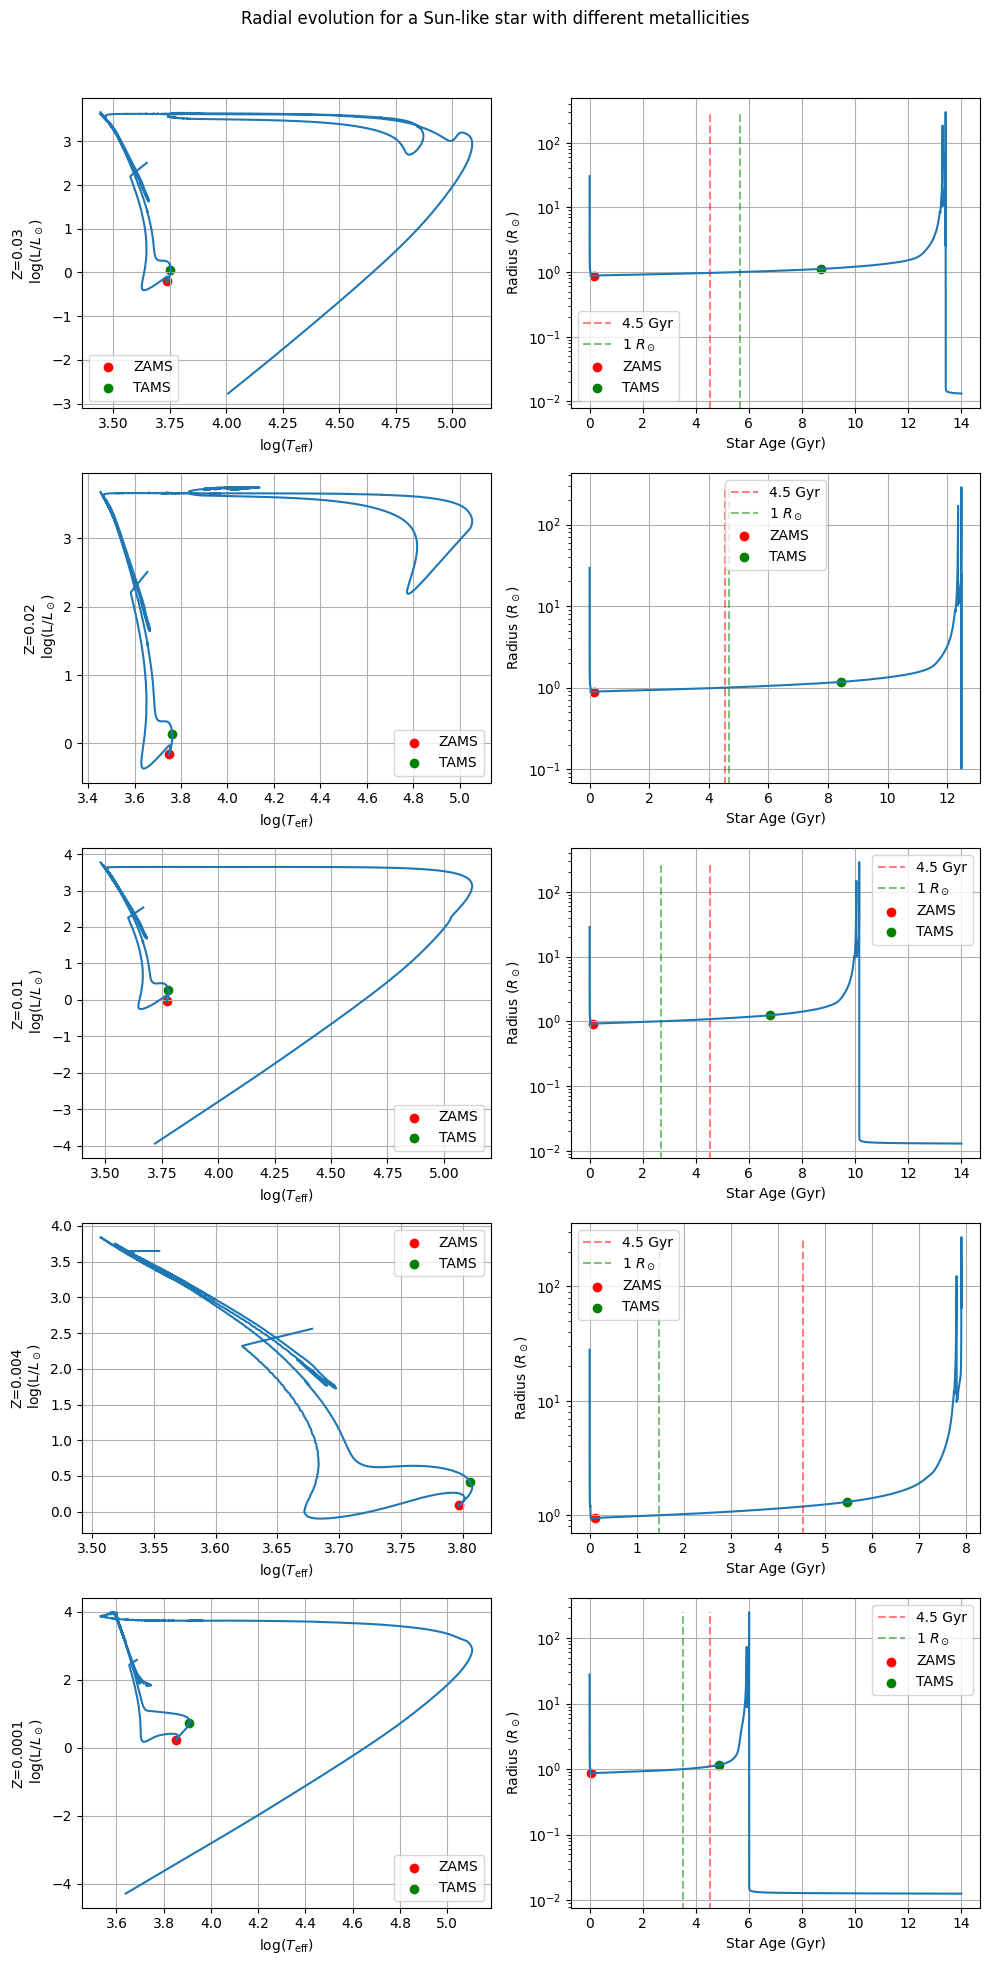

In [165]:
### Stellar evolution ###
def zams_and_tams(history_file):
    diffs = abs(history_file['center_h1']-(0.99*history_file['center_h1'][0]))
    zams = np.where(diffs == np.min(diffs))
    diffs = abs(history_file['center_h1']-(0.01*history_file['center_h1'][0]))
    tams = np.where(diffs == np.min(diffs))
    return zams, tams

def plot_hr_and_radial_profiles_cases(models_by_case, title, saveas):
    cases = list(models_by_case.keys())
    nC = len(cases)
    fig, axes = plt.subplots(nrows=nC,ncols=2,figsize=(10, 4 * nC),sharex=False,sharey=False)
    if nC == 1:
        axes = np.array([axes])
    fig.suptitle(title)
    for i, case in enumerate(cases):
        model = models_by_case[case]
        zams, tams = zams_and_tams(model)
        idx_age, idx_radius = np.argmin(np.abs(model['star_age'] - 4.5e9)), np.argmin(np.abs(10**model['log_R'] - 1))
        ax1, ax2 = axes[i]
        radius = 10**model['log_R']
        maxR = np.max(radius)
        # HR diagram
        ax1.plot(model['log_Teff'], model['log_L'])
        ax1.scatter(model['log_Teff'][zams], model['log_L'][zams], label='ZAMS', color='red')
        ax1.scatter(model['log_Teff'][tams], model['log_L'][tams], label='TAMS', color='green')
        ax1.legend()
        ax1.grid()
        ax1.set_xlabel(r'log($T_\mathrm{eff}$)')
        ax1.set_ylabel(f'{case}\n log(L'+r'/$L_\odot$)')
        # Radius vs. star age
        age = model['star_age'] / 1e9  # convert to Gyr
        ax2.plot(age, radius)
        ax2.vlines(age[idx_age], 0, maxR,linestyle='--', color='red', alpha=0.5, label='4.5 Gyr')
        ax2.vlines(age[idx_radius], 0, maxR,linestyle='--', color='green', alpha=0.5, label=r'1 $R_\odot$')
        ax2.scatter(age[zams], radius[zams], label='ZAMS', color='red')
        ax2.scatter(age[tams], radius[tams], label='TAMS', color='green')
        ax2.grid()
        ax2.set_xlabel('Star Age (Gyr)')
        ax2.set_ylabel(r'Radius ($R_\odot$)')
        ax2.set_yscale('log')
        ax2.legend(loc='best')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'Figures/{saveas}_radial_evolution_cases',dpi=500, bbox_inches='tight')
    plt.show()

models_by_case = {'Z=0.03': sun_z_0_03,'Z=0.02': sun_simple_model,'Z=0.01': sun_z_0_01,'Z=0.004': sun_z_0_004, 'Z=0.0001': sun_z_0_0001}
plot_hr_and_radial_profiles_cases(models_by_case, 'Radial evolution for a Sun-like star with different metallicities', 'metallicityradialprofiles')

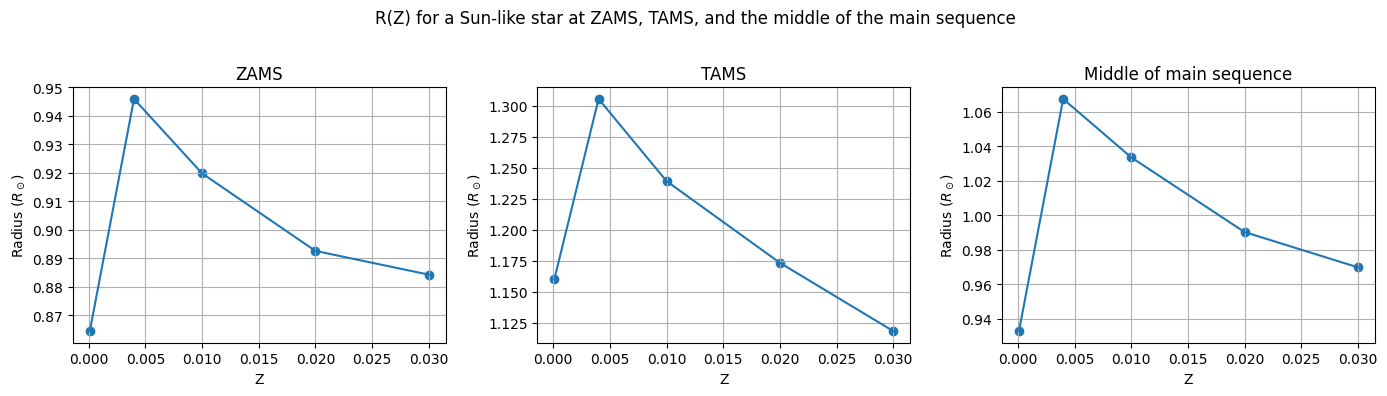

In [166]:
### R(Z) trend ###
def radius_vs_metallicity(z_vals, models_by_case, title):
    cases = list(models_by_case.keys())
    fig, (ax1, ax2, ax3)  = plt.subplots(nrows=1,ncols=3,figsize=(14, 4),sharex=False,sharey=False)
    fig.suptitle(title)
    
    zams_r_vals, tams_r_vals, middle_r_vals = [], [], []
    for i, case in enumerate(cases):
        model = models_by_case[case]
        zams, tams = zams_and_tams(model)
        middle_of_ms = zams[0][0]+round((tams[0][0]-zams[0][0])/2)
        zams_r_vals.append(10**model['log_R'][zams])
        tams_r_vals.append(10**model['log_R'][tams])
        middle_r_vals.append(10**model['log_R'][middle_of_ms])

    ax1.plot(z_vals, zams_r_vals)
    ax1.scatter(z_vals, zams_r_vals)                        
    ax1.set_xlabel('Z')
    ax1.set_ylabel(r'Radius ($R_\odot$)')
    ax1.set_title('ZAMS')
    ax1.grid()

    ax2.plot(z_vals, tams_r_vals)
    ax2.scatter(z_vals, tams_r_vals)
    ax2.set_xlabel('Z')
    ax2.set_ylabel(r'Radius ($R_\odot$)')
    ax2.set_title('TAMS')
    ax2.grid()

    ax3.plot(z_vals, middle_r_vals)
    ax3.scatter(z_vals, middle_r_vals)
    ax3.set_xlabel('Z')
    ax3.set_ylabel(r'Radius ($R_\odot$)')
    ax3.set_title('Middle of main sequence')
    ax3.grid()               
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'Figures/r_vs_z',dpi=500, bbox_inches='tight')
    plt.show()

z_vals = [0.03, 0.02, 0.01, 0.004, 0.0001]
models_by_case = {'Z=0.03': sun_z_0_03,'Z=0.02': sun_simple_model,'Z=0.01': sun_z_0_01,'Z=0.004': sun_z_0_004, 'Z=0.0001': sun_z_0_0001}
radius_vs_metallicity(z_vals, models_by_case, 'R(Z) for a Sun-like star at ZAMS, TAMS, and the middle of the main sequence')